# Public reproducible edition
Adapted from Ali Yaghi’s telecom study. By default this uses synthetic OOK signals. A local trace can be supplied but is not distributed. BER is measured relative to the clean decoded bits, not independently known transmitted bits for an external trace. Zero observed errors does not establish a zero population BER.



# DM n°1 — Réseaux et Télécom Optiques

**M2 OPTIQ — 2026-2027**

Ce notebook traite la trace `trace1.csv` de manière volontairement simple :

1. observation de la trace et de son spectre ;
2. identification des trois signaux multiplexés ;
3. démultiplexage et récupération des bits ;
4. décodage UTF-8 du message ;
5. proposition d'une chaîne d'émission télécom ;
6. ajout de bruit, calcul du SNR et du BER.

Le code est volontairement court et commenté.



## Données utiles du sujet

La trace contient le multiplexage de **trois signaux**.

Le sujet indique :

\[
f_s = 40\times10^3 \times BR
\]

Donc :

\[
\frac{f_s}{BR}=40000
\]

Il y a **40 000 échantillons par bit**.

Les bits sont regroupés par octets de 8 bits puis décodés en **UTF-8**.  
Les trois chaînes obtenues sont ensuite concaténées.


In [1]:

import os
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True



# 1. Lecture et observation de la trace


In [2]:
# Supply your own authorized trace1.csv locally, or run this synthetic example.
from pathlib import Path
if Path("trace1.csv").exists():
    trace = np.loadtxt("trace1.csv", delimiter=",", ndmin=2)[:,0]
else:
    texts = ["Optics demo ", "Python demo ", "Signal demo "]
    bit_arrays = [np.unpackbits(np.frombuffer(t.encode("utf-8"), dtype=np.uint8)) for t in texts]
    n = np.arange(len(bit_arrays[0])*40000)
    trace = sum(np.repeat(b,40000)*np.cos(2*np.pi*f*n) for b,f in zip(bit_arrays,[.2475,.2500,.2525]))
print("Samples:", len(trace))


Samples: 3840000


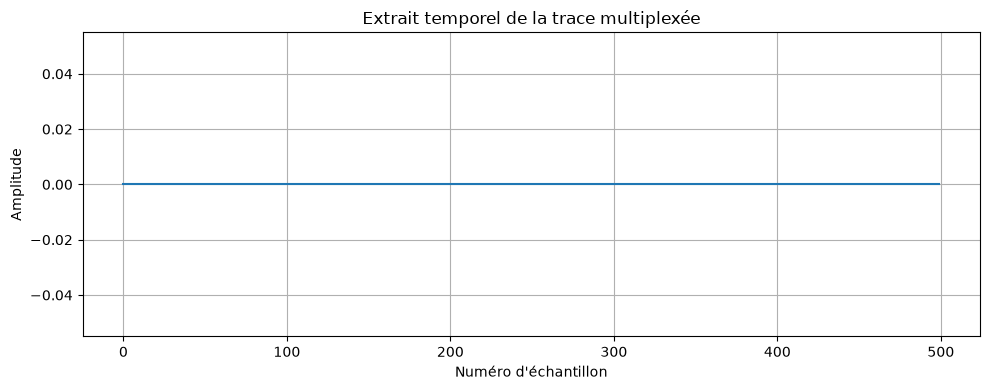

In [3]:

# Court extrait temporel
n_aff = 500

plt.figure()
plt.plot(np.arange(n_aff), trace[:n_aff])
plt.xlabel("Numéro d'échantillon")
plt.ylabel("Amplitude")
plt.title("Extrait temporel de la trace multiplexée")
plt.tight_layout()
plt.show()



La trace temporelle est difficile à interpréter directement car plusieurs porteuses rapides sont superposées.  
On regarde donc son spectre à l'aide d'une FFT.


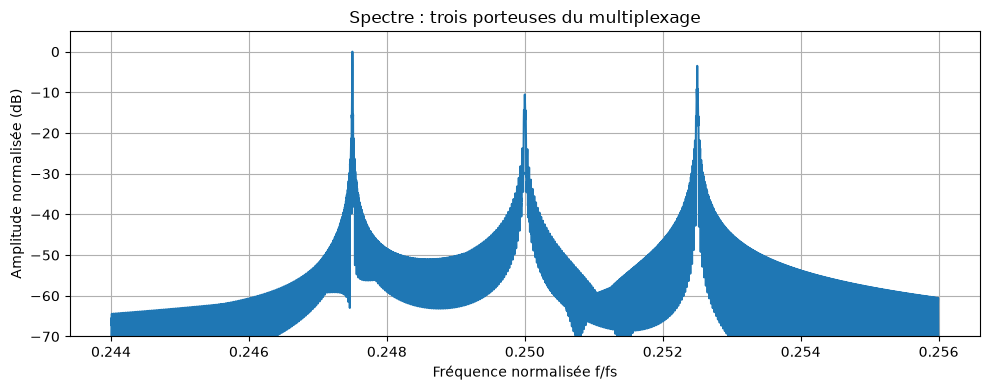

In [4]:

# On utilise 400 000 échantillons : c'est suffisant pour séparer les porteuses.
N_FFT = 400_000

x_fft = trace[:N_FFT] - np.mean(trace[:N_FFT])
window = np.hanning(N_FFT)

spectrum = np.abs(np.fft.rfft(x_fft * window))
freq = np.fft.rfftfreq(N_FFT, d=1.0)  # fréquence normalisée f/fs

# Spectre normalisé en dB
spectrum_db = 20*np.log10(spectrum / np.max(spectrum) + 1e-15)

mask = (freq >= 0.244) & (freq <= 0.256)

plt.figure()
plt.plot(freq[mask], spectrum_db[mask])
plt.xlabel("Fréquence normalisée f/fs")
plt.ylabel("Amplitude normalisée (dB)")
plt.title("Spectre : trois porteuses du multiplexage")
plt.ylim(-70, 5)
plt.tight_layout()
plt.show()


In [5]:

# Recherche simple du maximum dans trois bandes autour de fs/4.
bands = [(0.246, 0.249), (0.249, 0.251), (0.251, 0.254)]

carrier_fracs = []

for fmin, fmax in bands:
    m = (freq >= fmin) & (freq <= fmax)
    idx = np.argmax(spectrum[m])
    carrier_fracs.append(freq[m][idx])

carrier_fracs = np.array(carrier_fracs)

# Conversion en multiples de BR :
# fc/BR = (fc/fs) * (fs/BR)
carrier_over_BR = carrier_fracs * 40_000

for i, (ff, fbr) in enumerate(zip(carrier_fracs, carrier_over_BR), start=1):
    print(f"Porteuse {i} : fc/fs = {ff:.6f}  soit environ {fbr:.0f} × BR")


Porteuse 1 : fc/fs = 0.247500  soit environ 9900 × BR
Porteuse 2 : fc/fs = 0.250000  soit environ 10000 × BR
Porteuse 3 : fc/fs = 0.252500  soit environ 10100 × BR



On trouve :

\[
f_1 \approx 0{,}2475f_s,\qquad
f_2 \approx 0{,}2500f_s,\qquad
f_3 \approx 0{,}2525f_s
\]

soit environ :

\[
9900\,BR,\qquad 10000\,BR,\qquad 10100\,BR.
\]

Le multiplexage observé est donc un **multiplexage fréquentiel**.



# 2. Démultiplexage et récupération des bits

Il y a **40 000 échantillons par bit**.

Pour chaque durée de bit et pour chaque porteuse, on calcule deux corrélations :

\[
I=\frac{2}{N}\sum x[n]\cos(2\pi f_c n)
\]

\[
Q=\frac{2}{N}\sum x[n]\sin(2\pi f_c n)
\]

Puis :

\[
A=\sqrt{I^2+Q^2}.
\]

Cette méthode correspond à une démodulation synchrone simple.


In [6]:

SAMPLES_PER_BIT = 40_000
N_BITS = len(trace) // SAMPLES_PER_BIT

print("Nombre de bits par canal  :", N_BITS)
print("Nombre d'octets par canal:", N_BITS // 8)


Nombre de bits par canal  : 96
Nombre d'octets par canal: 12


In [7]:

def demodulate_amplitudes(signal, carriers, samples_per_bit=40_000):
    # Nombre de bits complets
    n_bits = len(signal) // samples_per_bit

    # Un bloc = une durée de bit
    blocks = signal[:n_bits*samples_per_bit].reshape(n_bits, samples_per_bit)

    n = np.arange(samples_per_bit)
    amplitudes = []

    for fc in carriers:
        # Porteuse de référence
        c = np.cos(2*np.pi*fc*n)
        s = np.sin(2*np.pi*fc*n)

        # Corrélation I/Q
        I = (2/samples_per_bit) * (blocks @ c)
        Q = (2/samples_per_bit) * (blocks @ s)

        # Amplitude de la porteuse pendant chaque bit
        amplitudes.append(np.sqrt(I**2 + Q**2))

    return amplitudes


amplitudes = demodulate_amplitudes(trace, carrier_fracs)


In [8]:

def threshold_from_largest_gap(values):
    # Les amplitudes forment deux groupes : bit 0 et bit 1.
    ordered = np.sort(values)
    gaps = np.diff(ordered)

    # Le plus grand espace sépare naturellement les deux groupes.
    k = np.argmax(gaps)

    return (ordered[k] + ordered[k+1]) / 2


thresholds = [threshold_from_largest_gap(a) for a in amplitudes]

for i, th in enumerate(thresholds, start=1):
    print(f"Seuil canal {i} : {th:.2f}")


Seuil canal 1 : 0.50
Seuil canal 2 : 0.50
Seuil canal 3 : 0.50


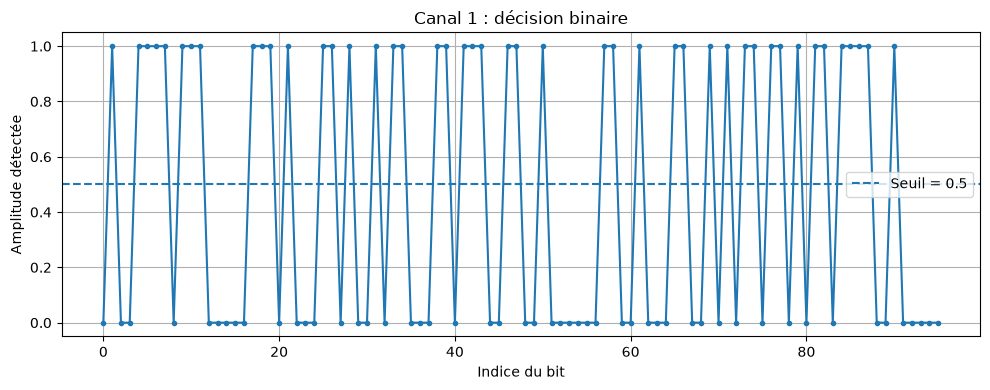

In [9]:

i = 0

plt.figure()
plt.plot(np.arange(N_BITS), amplitudes[i], "o-", markersize=3)
plt.axhline(
    thresholds[i],
    linestyle="--",
    label=f"Seuil = {thresholds[i]:.1f}"
)
plt.xlabel("Indice du bit")
plt.ylabel("Amplitude détectée")
plt.title("Canal 1 : décision binaire")
plt.legend()
plt.tight_layout()
plt.show()


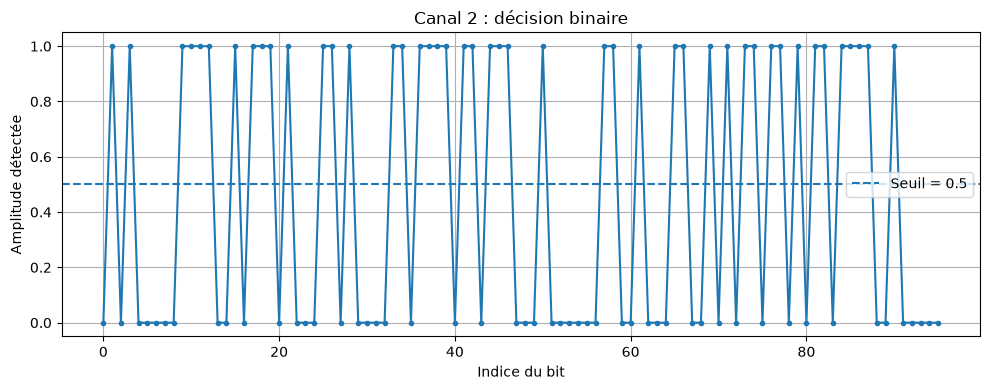

In [10]:

i = 1

plt.figure()
plt.plot(np.arange(N_BITS), amplitudes[i], "o-", markersize=3)
plt.axhline(
    thresholds[i],
    linestyle="--",
    label=f"Seuil = {thresholds[i]:.1f}"
)
plt.xlabel("Indice du bit")
plt.ylabel("Amplitude détectée")
plt.title("Canal 2 : décision binaire")
plt.legend()
plt.tight_layout()
plt.show()


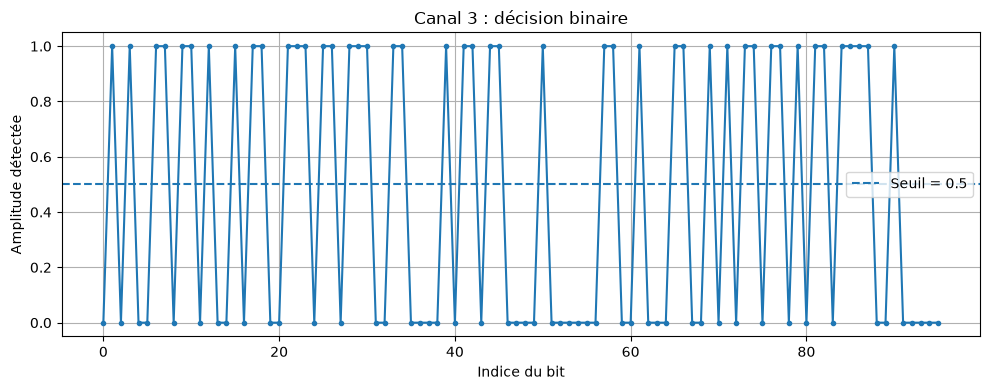

In [11]:

i = 2

plt.figure()
plt.plot(np.arange(N_BITS), amplitudes[i], "o-", markersize=3)
plt.axhline(
    thresholds[i],
    linestyle="--",
    label=f"Seuil = {thresholds[i]:.1f}"
)
plt.xlabel("Indice du bit")
plt.ylabel("Amplitude détectée")
plt.title("Canal 3 : décision binaire")
plt.legend()
plt.tight_layout()
plt.show()



Les deux niveaux d'amplitude sont bien séparés :

- amplitude inférieure au seuil → **0** ;
- amplitude supérieure au seuil → **1**.


In [12]:

reference_bits = [
    (amp > th).astype(np.uint8)
    for amp, th in zip(amplitudes, thresholds)
]

for i, bits in enumerate(reference_bits, start=1):
    first_bits = "".join(str(int(b)) for b in bits[:32])
    print(f"Canal {i} - 32 premiers bits : {first_bits}")


Canal 1 - 32 premiers bits : 01001111011100000111010001101001
Canal 2 - 32 premiers bits : 01010000011110010111010001101000
Canal 3 - 32 premiers bits : 01010011011010010110011101101110



## Décodage UTF-8


In [13]:

def bits_to_text(bits):
    # Conversion des bits en une chaîne de 0 et 1
    bit_string = "".join(str(int(b)) for b in bits)

    # Découpage en octets de 8 bits
    octets = [
        bit_string[i:i+8]
        for i in range(0, len(bit_string), 8)
    ]

    # Conversion octets -> bytes -> texte UTF-8
    data = bytes(int(octet, 2) for octet in octets)

    return data.decode("utf-8", errors="replace")


texts = [bits_to_text(bits) for bits in reference_bits]

for i, txt in enumerate(texts, start=1):
    print(f"Canal {i} : {txt!r}")

message = "".join(texts)

print()
print("MESSAGE COMPLET :")
print(message)


Canal 1 : 'Optics demo '
Canal 2 : 'Python demo '
Canal 3 : 'Signal demo '

MESSAGE COMPLET :
Optics demo Python demo Signal demo 


Résultats : voir les sorties recalculées ci-dessous. Le mode par défaut emploie des données synthétiques.


# 3. Comment envoyer une réponse ?

La trace étudiée contient trois **sous-porteuses RF**.  
Une réalisation expérimentale cohérente consiste à utiliser un système de **Subcarrier Multiplexing (SCM)**.

## Côté émission

1. **Ordinateur / FPGA** : transforme la réponse en UTF-8 puis en bits.
2. Le message est séparé en **trois flux binaires**.
3. Trois **oscillateurs RF** génèrent les trois porteuses.
4. Chaque flux binaire module l'amplitude de sa porteuse.
5. Un **sommateur RF** additionne les trois voies.
6. Un **laser continu** fournit la porteuse optique.
7. Un **modulateur Mach-Zehnder (MZM)** module la lumière avec le signal électrique multiplexé.
8. La lumière est injectée dans la **fibre optique**.

## Côté réception

1. **Photodiode rapide**
2. **Amplificateur transimpédance (TIA)**
3. **ADC / oscilloscope**
4. **Démultiplexage et décodage numérique**

### Composants actifs

Laser, FPGA/DAC, oscillateurs RF, modulateur MZM, amplificateurs, photodiode/TIA, ADC.

### Composants passifs

Fibre optique, connecteurs, coupleurs, atténuateurs et filtres passifs éventuels.


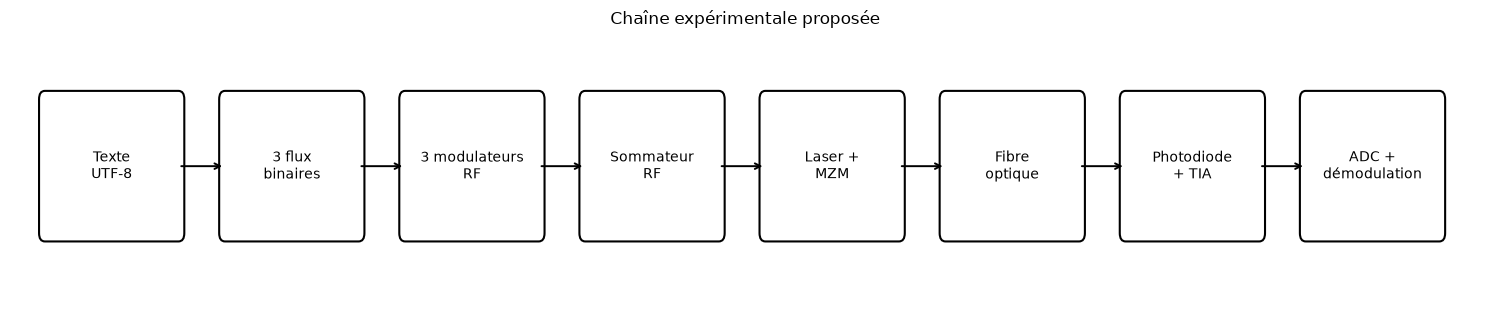

In [14]:

# Schéma simple de la chaîne de transmission
import matplotlib.patches as patches

labels = [
    "Texte\nUTF-8",
    "3 flux\nbinaires",
    "3 modulateurs\nRF",
    "Sommateur\nRF",
    "Laser +\nMZM",
    "Fibre\noptique",
    "Photodiode\n+ TIA",
    "ADC +\ndémodulation"
]

xpos = np.arange(len(labels)) * 1.55

fig, ax = plt.subplots(figsize=(15, 3.2))

for x0, label in zip(xpos, labels):
    rect = patches.FancyBboxPatch(
        (x0, 0),
        1.15,
        0.8,
        boxstyle="round,pad=0.05",
        fill=False,
        linewidth=1.5
    )
    ax.add_patch(rect)
    ax.text(
        x0 + 0.575,
        0.4,
        label,
        ha="center",
        va="center",
        fontsize=10
    )

for i in range(len(labels)-1):
    ax.annotate(
        "",
        xy=(xpos[i+1], 0.4),
        xytext=(xpos[i] + 1.15, 0.4),
        arrowprops=dict(arrowstyle="->", linewidth=1.4)
    )

ax.set_xlim(-0.3, xpos[-1] + 1.5)
ax.set_ylim(-0.4, 1.2)
ax.axis("off")
ax.set_title("Chaîne expérimentale proposée")
plt.tight_layout()
plt.show()



# 4. Ajout de bruit — SNR et BER

Le sujet demande d'ajouter artificiellement du bruit de **3 dB, 6 dB et 10 dB**.

Le niveau de bruit n'étant pas défini plus précisément, on adopte la convention suivante :

> **3, 6 et 10 dB sont les SNR visés après ajout d'un bruit blanc gaussien (AWGN).**

On enlève la composante continue pour calculer la puissance utile :

\[
P_s=\frac{1}{N}\sum (x[n]-\bar{x})^2
\]

Puis :

\[
P_n=\frac{P_s}{10^{SNR_{dB}/10}}
\]

et :

\[
SNR_{dB}=10\log_{10}\left(\frac{P_s}{P_n}\right).
\]

Enfin :

\[
BER=\frac{N_{\text{bits erronés}}}{N_{\text{bits transmis}}}.
\]

La comparaison porte sur \(3\times96=288\) bits.


In [15]:

def add_awgn(signal, target_snr_db, rng):
    # Puissance du signal sans la composante continue
    signal_ac = signal - np.mean(signal)
    p_signal = np.mean(signal_ac**2)

    # Puissance de bruit nécessaire pour obtenir le SNR demandé
    snr_linear = 10**(target_snr_db / 10)
    p_noise_target = p_signal / snr_linear

    # Bruit blanc gaussien
    noise = rng.normal(
        0.0,
        np.sqrt(p_noise_target),
        size=len(signal)
    )

    noisy_signal = signal + noise

    # SNR réellement obtenu
    p_noise_measured = np.mean(noise**2)
    measured_snr_db = 10*np.log10(
        p_signal / p_noise_measured
    )

    return noisy_signal, measured_snr_db


In [16]:

# Même méthode de traitement dans tous les cas :
# - mêmes porteuses
# - mêmes seuils
# - même décision binaire

rng = np.random.default_rng(12345)

results = []
short_noisy_traces = {}

for target_snr in [3, 6, 10]:
    noisy, measured_snr = add_awgn(
        trace,
        target_snr,
        rng
    )

    noisy_amplitudes = demodulate_amplitudes(
        noisy,
        carrier_fracs,
        SAMPLES_PER_BIT
    )

    noisy_bits = [
        (amp > th).astype(np.uint8)
        for amp, th in zip(noisy_amplitudes, thresholds)
    ]

    noisy_texts = [
        bits_to_text(bits)
        for bits in noisy_bits
    ]

    decoded_message = "".join(noisy_texts)

    n_errors = sum(
        int(np.sum(bits_n != bits_ref))
        for bits_n, bits_ref in zip(noisy_bits, reference_bits)
    )

    n_total = sum(len(bits) for bits in reference_bits)

    ber = n_errors / n_total

    results.append({
        "SNR cible (dB)": target_snr,
        "SNR mesuré (dB)": measured_snr,
        "Erreurs bits": n_errors,
        "Bits comparés": n_total,
        "BER": ber,
        "Message obtenu": decoded_message
    })

    # On conserve un extrait seulement pour le graphique.
    short_noisy_traces[target_snr] = noisy[:500].copy()

results


[{'SNR cible (dB)': 3,
  'SNR mesuré (dB)': np.float64(2.9961615657383227),
  'Erreurs bits': 0,
  'Bits comparés': 288,
  'BER': 0.0,
  'Message obtenu': 'Optics demo Python demo Signal demo '},
 {'SNR cible (dB)': 6,
  'SNR mesuré (dB)': np.float64(5.997834864585238),
  'Erreurs bits': 0,
  'Bits comparés': 288,
  'BER': 0.0,
  'Message obtenu': 'Optics demo Python demo Signal demo '},
 {'SNR cible (dB)': 10,
  'SNR mesuré (dB)': np.float64(9.99329732224345),
  'Erreurs bits': 0,
  'Bits comparés': 288,
  'BER': 0.0,
  'Message obtenu': 'Optics demo Python demo Signal demo '}]

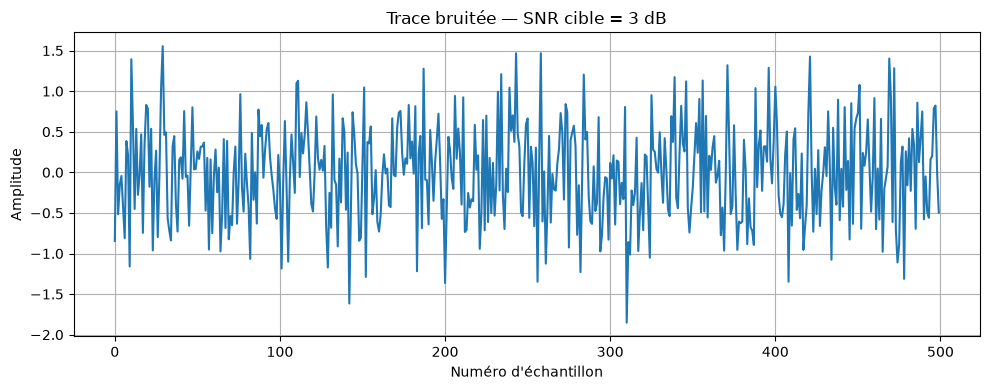

In [17]:

plt.figure()
plt.plot(np.arange(500), short_noisy_traces[3])
plt.xlabel("Numéro d'échantillon")
plt.ylabel("Amplitude")
plt.title("Trace bruitée — SNR cible = 3 dB")
plt.tight_layout()
plt.show()


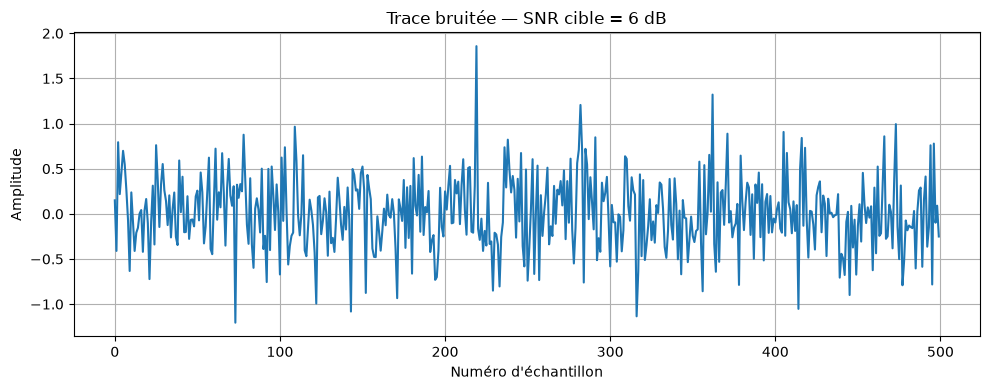

In [18]:

plt.figure()
plt.plot(np.arange(500), short_noisy_traces[6])
plt.xlabel("Numéro d'échantillon")
plt.ylabel("Amplitude")
plt.title("Trace bruitée — SNR cible = 6 dB")
plt.tight_layout()
plt.show()


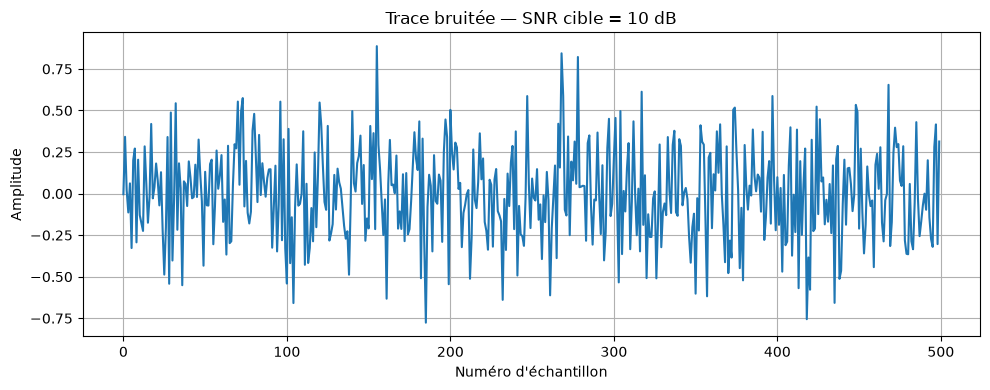

In [19]:

plt.figure()
plt.plot(np.arange(500), short_noisy_traces[10])
plt.xlabel("Numéro d'échantillon")
plt.ylabel("Amplitude")
plt.title("Trace bruitée — SNR cible = 10 dB")
plt.tight_layout()
plt.show()



## Interprétation de la question 3

Avec cette convention de bruit AWGN, le message est encore correctement récupéré pour les trois niveaux testés et le **BER mesuré reste nul**.

Cela s'explique notamment par le grand nombre d'échantillons disponibles par bit : la corrélation moyenne l'information sur **40 000 échantillons**, alors que le bruit blanc est en grande partie moyenné.

Un BER nul signifie ici qu'aucune erreur n'a été observée sur les **288 bits testés**.  
Il ne faut pas interpréter cela comme un BER théorique strictement nul sur une liaison réelle.

### Approche expérimentale réelle

Pour reproduire cette étude sur une vraie liaison :

- ajouter un bruit électrique contrôlé ou diminuer la puissance reçue avec un atténuateur optique ;
- mesurer signal et bruit avec un oscilloscope ou un analyseur de spectre ;
- conserver exactement le même récepteur ;
- comparer les bits reçus à une séquence connue ;
- calculer le BER avec un **BERT** (*Bit Error Rate Tester*).

En pratique, il faudrait transmettre beaucoup plus de 288 bits pour mesurer correctement un faible BER.


Résultats : voir les sorties recalculées ci-dessous. Le mode par défaut emploie des données synthétiques.